# ASSIGNMENT 9 : DATA PREPROCESSING & FEATURE ENGINEERING IN ML – ADULT DATASET

In [1]:

# DATA PREPROCESSING & FEATURE ENGINEERING – ADULT DATASET


# 1. Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# 2. Load the Dataset

df = pd.read_csv("adult_with_headers.csv")


In [3]:

# 3. Basic Data Exploration


# Display first few rows
df.head()

# Dataset information (data types & null values)
df.info()

# Summary statistics for numerical columns
df.describe()

# Check missing values count
df.isnull().sum()

# Replace '?' values with NaN (Adult dataset common issue)
df.replace(" ?", np.nan, inplace=True)

# Check missing values again
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [4]:

# 4. Handle Missing Values (Best Practices)


# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Impute numerical columns with median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute categorical columns with most frequent value (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Confirm missing values handled
df.isnull().sum()



age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [ ]:

# 5. Scaling Techniques

# Select numerical features for scaling
numerical_features = [
    'age', 'fnlwgt', 'education_num',
    'capital_gain', 'capital_loss',
    'hours_per_week'
]

# a) Standard Scaling 
standard_scaler = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[numerical_features] = standard_scaler.fit_transform(
    df[numerical_features]
)

# b) Min-Max Scaling 
minmax_scaler = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[numerical_features] = minmax_scaler.fit_transform(
    df[numerical_features]
)


# SCALING DISCUSSION (COMMENT)

# Standard Scaling:
# - Centers data around mean = 0 and std = 1
# - Best for algorithms like Logistic Regression, SVM, PCA
# - Sensitive to outliers

# Min-Max Scaling:
# - Scales data to range [0, 1]
# - Best for Neural Networks, distance-based algorithms
# - Sensitive to extreme values



In [6]:

# 6. Encoding Techniques


# Count unique values in categorical features
df[cat_cols].nunique()

# Categorical columns with <= 5 categories (One-Hot Encoding)
one_hot_cols = [col for col in cat_cols if df[col].nunique() <= 5]

# Columns with > 5 categories (Label Encoding)
label_encode_cols = [col for col in cat_cols if df[col].nunique() > 5]

# -------- One-Hot Encoding --------
df_encoded = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

# -------- Label Encoding --------
le = LabelEncoder()
for col in label_encode_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


# ENCODING DISCUSSION (COMMENT)

# One-Hot Encoding:
# Pros:
# - No ordinal relationship imposed
# - Best for nominal categories
# Cons:
# - Increases dimensionality

# Label Encoding:
# Pros:
# - Saves memory
# - Simple and fast
# Cons:
# - Introduces false ordinal relationship
# - Can mislead linear models



In [ ]:

# 7. Feature Engineering


# New Feature 1 
# Income per hour worked
df_encoded['income_per_hour'] = df['capital_gain'] / (df['hours_per_week'] + 1)

# Rationale:
# - Captures earning efficiency relative to work hours

#  New Feature 2 
# Total capital (gain - loss)
df_encoded['total_capital'] = df['capital_gain'] - df['capital_loss']

# Rationale:
# - Net investment benefit better than separate features



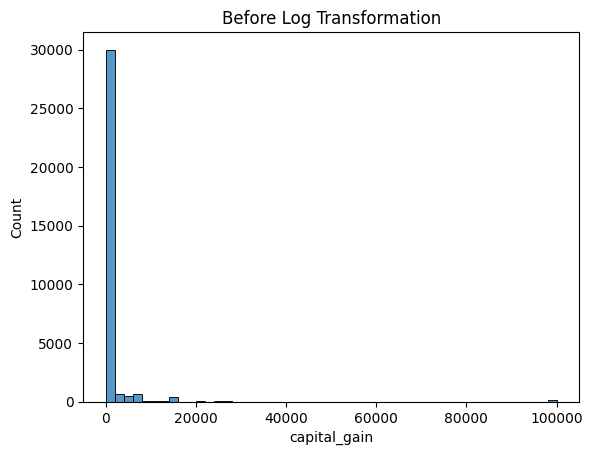

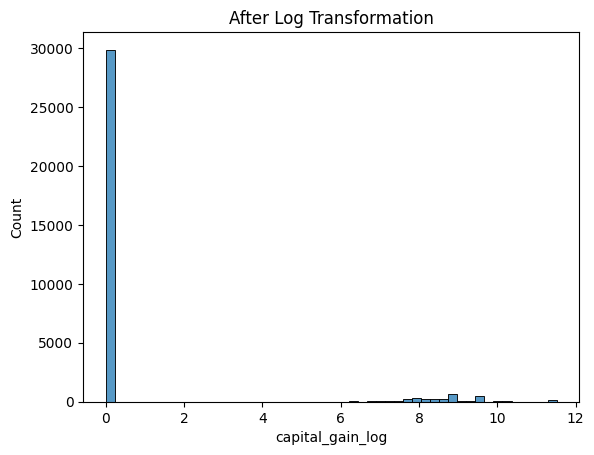

In [8]:

# 8. Feature Transformation (Log Transformation)


# Capital gain is heavily right-skewed
sns.histplot(df['capital_gain'], bins=50)
plt.title("Before Log Transformation")
plt.show()

# Apply log transformation
df_encoded['capital_gain_log'] = np.log1p(df['capital_gain'])

# Visualize after transformation
sns.histplot(df_encoded['capital_gain_log'], bins=50)
plt.title("After Log Transformation")
plt.show()

# Justification:
# - Log transformation reduces skewness
# - Improves model performance for linear models


In [9]:

# 9. Outlier Detection using Isolation Forest


iso_forest = IsolationForest(contamination=0.01, random_state=42)
df_encoded['outlier'] = iso_forest.fit_predict(
    df_encoded[numerical_features]
)

# -1 indicates outliers
df_encoded['outlier'].value_counts()



outlier
 1    32235
-1      326
Name: count, dtype: int64

In [10]:

# FINAL DATASET SHAPE

df_encoded.shape

# Dataset ready for Machine Learning

(32561, 22)